In [2]:
from models.lcamazon import LCAmazon


dataset=LCAmazon(root="DATA", modality="s2", split="train")
print(f"dataset of length {len(dataset)}")

dataset of length 4250


là on plot

In [7]:
import numpy as np
img, sffsa = dataset[0]
print(np.shape(img))

(47, 47, 12)


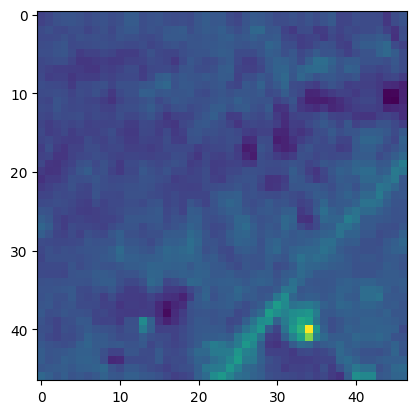

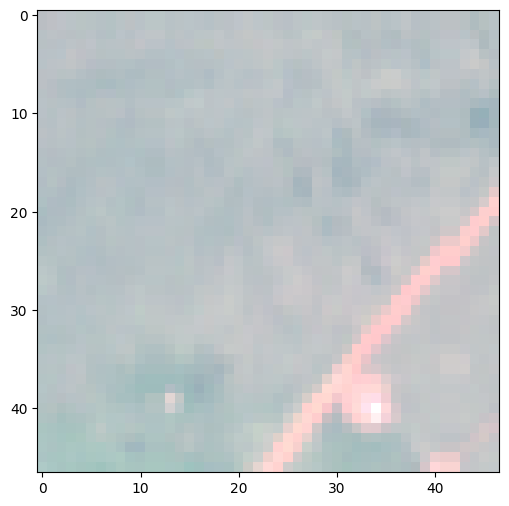

interactive(children=(Dropdown(description='idx', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1…

In [9]:
# plot individual samples
from ipywidgets import interact
import matplotlib.pyplot as plt
@interact(idx=range(len(dataset)))
def plot_sample(idx=0):
    img, label = dataset[idx]
    red   = img[:, :, 3]   # Band 4
    green = img[:, :, 2]   # Band 3
    blue  = img[:, :, 1]   # Band 2
    plt.imshow(img[:,:,2])
    rgb = np.stack([red, green, blue], axis=-1).astype(np.float32)

    # Normalize for display
    rgb /= np.percentile(rgb, 99)
    rgb = np.clip(rgb, 0, 1)

    # --- Plot ---
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)

    # swaps keys and values in the dictionary LCAmazon.LABEL_CLASSES
    class_mapping = {v: k for k, v in LCAmazon.LABEL_CLASSES.items()}

    plt.title(f"classid {label} ({class_mapping[label]})")